# Pregunta 1 - LaLonde: IPW, modelos de resultado y DAG

Este notebook responde la primera pregunta del examen usando el archivo `Datos Lalonde.csv`.

El objetivo es estimar el efecto causal del programa de entrenamiento laboral sobre los ingresos de 1978 (`re78`) mediante puntaje de propension, IPW y modelado de resultados. Tambien se construye un DAG causal plausible y se determina el conjunto de ajuste por backdoor.

## Nota metodologica sobre el dataset

Aunque LaLonde suele asociarse con el experimento NSW, el archivo usado aqui no corresponde al ensayo experimental puro. Los individuos tratados tienen identificadores `NSW`, mientras que los controles tienen identificadores `PSID`.

Por lo tanto, este analisis se trata como un estudio observacional con tratados NSW y controles PSID. El efecto causal no se identifica por aleatorizacion simple, sino bajo el supuesto de ignorabilidad condicional dado el conjunto de covariables pretratamiento:

`X = {age, educ, black, hispan, married, nodegree, re74, re75}`.

No se utiliza `ID` como covariable porque codifica el origen de la muestra y separa perfectamente tratamiento/control. Tampoco se ajusta por `re78`, ya que es la variable de resultado posterior al tratamiento.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("default")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
BASE_DIR = Path("..")
DATA_PATH = BASE_DIR / "data" / "input" / "Datos Lalonde.csv"
OUTPUT_DIR = BASE_DIR / "data" / "output" / "pregunta1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df.head()

,ID,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
0,NSW1,1,37,11,1,0,1,1,0.0000,0.0000,"9,930.0460"
1,NSW2,1,22,9,0,1,0,1,0.0000,0.0000,"3,595.8940"
2,NSW3,1,30,12,1,0,0,0,0.0000,0.0000,"24,909.4500"
3,NSW4,1,27,11,1,0,0,1,0.0000,0.0000,"7,506.1460"
4,NSW5,1,33,8,1,0,0,1,0.0000,0.0000,289.7899


In [3]:
print(df.shape)
print(df.columns.tolist())
df.isna().sum()

(614, 11)
['ID', 'treat', 'age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75', 're78']


ID          0
treat       0
age         0
educ        0
black       0
hispan      0
married     0
nodegree    0
re74        0
re75        0
re78        0
dtype: int64

In [4]:
df["source"] = df["ID"].str.extract(r"^([A-Za-z]+)")
pd.crosstab(df["source"], df["treat"], margins=True)

treat,0,1,All
source,,,
NSW,0,185,185
PSID,429,0,429
All,429,185,614


La tabla anterior confirma el punto metodologico central: todos los tratados son `NSW` y todos los controles son `PSID`. Por eso `ID` o cualquier variable derivada de `source` no debe incorporarse al modelo de propension ni al modelo de resultados.

In [5]:
D = "treat"
Y = "re78"
X_cols = ["age", "educ", "black", "hispan", "married", "nodegree", "re74", "re75"]

df.groupby(D)[X_cols + [Y]].mean().T

treat,0,1
age,28.0303,25.8162
educ,10.2354,10.3459
black,0.2028,0.8432
hispan,0.1422,0.0595
married,0.5128,0.1892
nodegree,0.5967,0.7081
re74,"5,619.2365","2,095.5737"
re75,"2,466.4844","1,532.0553"
re78,"6,984.1697","6,349.1435"


Las medias por grupo sugieren diferencias importantes antes del tratamiento. En particular, los ingresos previos (`re74`, `re75`) y la composicion racial difieren de forma clara entre tratados y controles. Esto anticipa problemas potenciales de solapamiento/positividad.

## Puntaje de propension

Estimamos el puntaje de propension:

`e(X) = P(D = 1 | X)`

usando una regresion logistica con covariables pretratamiento. El objetivo no es predecir por si mismo, sino evaluar solapamiento y construir pesos IPW.

In [6]:
X = df[X_cols]
d = df[D].to_numpy()
y = df[Y].to_numpy()

propensity_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=10_000, solver="lbfgs")),
])

propensity_model.fit(X, d)
df["propensity"] = propensity_model.predict_proba(X)[:, 1]

auc = roc_auc_score(d, df["propensity"])
print(f"AUC del modelo de propension: {auc:.3f}")
df.groupby(D)["propensity"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

AUC del modelo de propension: 0.874


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
treat,,,,,,,,,,,,
0,429.0000,0.1834,0.2274,0.0101,0.0120,0.0180,0.0411,0.0798,0.1943,0.7016,0.7460,0.7824
1,185.0000,0.5748,0.2176,0.0269,0.0455,0.0994,0.5267,0.6517,0.7222,0.7721,0.8080,0.8442


PosixPath('../data/output/pregunta1/propensity_overlap.png')

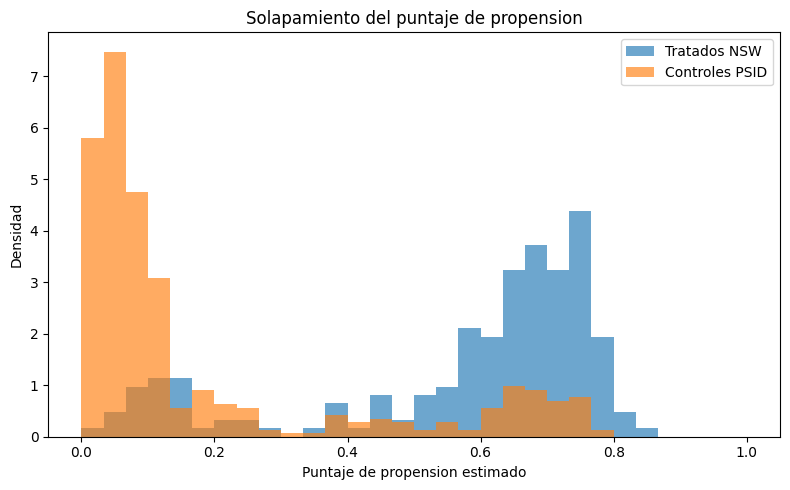

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(0, 1, 31)
ax.hist(df.loc[df[D] == 1, "propensity"], bins=bins, alpha=0.65, density=True, label="Tratados NSW")
ax.hist(df.loc[df[D] == 0, "propensity"], bins=bins, alpha=0.65, density=True, label="Controles PSID")
ax.set_xlabel("Puntaje de propension estimado")
ax.set_ylabel("Densidad")
ax.set_title("Solapamiento del puntaje de propension")
ax.legend()
fig.tight_layout()

plot_path = OUTPUT_DIR / "propensity_overlap.png"
fig.savefig(plot_path, dpi=160)
plot_path

La distribucion del puntaje de propension debe interpretarse como diagnostico de positividad. Si hay muchas observaciones cerca de 0 o 1, los pesos IPW pueden volverse extremos. En este caso el modelo distingue bastante bien tratados de controles, lo que es consistente con el origen NSW vs PSID y sugiere solapamiento imperfecto.

## Pesos IPW para ATE

Para ATE se usan pesos:

`w_i = D_i / e(X_i) + (1 - D_i) / (1 - e(X_i))`

Tambien calculamos una version estabilizada/normalizada por grupo para revisar sensibilidad a pesos extremos.

In [8]:
eps = 0.01
df["propensity_clipped"] = df["propensity"].clip(eps, 1 - eps)

e = df["propensity_clipped"].to_numpy()
df["w_ate"] = d / e + (1 - d) / (1 - e)
df["w_att"] = np.where(d == 1, 1.0, e / (1 - e))

df["w_ate"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count   614.0000
mean      1.8850
std       2.4680
min       1.0102
50%       1.1762
90%       3.1346
95%       4.0079
99%      11.9937
max      37.2368
Name: w_ate, dtype: float64

In [9]:
df.sort_values("w_ate", ascending=False)[
    ["ID", D, "age", "educ", "black", "hispan", "married", "nodegree", "re74", "re75", Y, "propensity", "w_ate"]
].head(10)

,ID,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78,propensity,w_ate
123,NSW124,1,27,13,0,0,1,0,"9,381.5660",853.7225,0.0000,0.0269,37.2368
9,NSW10,1,33,12,0,0,1,0,0.0000,0.0000,"12,418.0700",0.0453,22.0676
136,NSW137,1,23,8,0,0,1,1,0.0000,"1,713.1500","4,232.3090",0.0455,21.9767
115,NSW116,1,21,12,0,0,0,0,"3,670.8720",334.0494,"12,558.0200",0.0665,15.0437
67,NSW68,1,23,7,0,0,0,1,0.0000,0.0000,0.0000,0.0785,12.7314
178,NSW179,1,22,12,0,0,0,0,"6,759.9940","8,455.5040","12,590.7100",0.0805,12.4246
88,NSW89,1,21,12,0,0,0,0,0.0000,0.0000,"8,048.6030",0.0828,12.0758
95,NSW96,1,25,12,0,0,0,0,0.0000,0.0000,"5,587.5030",0.0874,11.4439
43,NSW44,1,18,8,0,1,1,1,0.0000,0.0000,"2,787.9600",0.0926,10.8027
41,NSW42,1,19,9,0,0,0,1,0.0000,0.0000,"13,188.8300",0.0983,10.1705


Los pesos mas grandes corresponden a unidades observadas en un grupo para el que el modelo les asignaba baja probabilidad. Este es un diagnostico importante: IPW puede corregir desbalance observado, pero tambien puede volverse sensible cuando la positividad practica es debil.

## Balance de covariables

Usamos diferencias de medias estandarizadas (SMD) antes y despues de ponderar por IPW. Valores absolutos mas cercanos a cero indican mejor balance.

In [10]:
def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)


def weighted_var(x, w):
    mu = weighted_mean(x, w)
    return np.sum(w * (x - mu) ** 2) / np.sum(w)


def smd(x, treat, weights=None):
    x = np.asarray(x, dtype=float)
    treat = np.asarray(treat)

    if weights is None:
        x1, x0 = x[treat == 1], x[treat == 0]
        m1, m0 = x1.mean(), x0.mean()
        v1, v0 = x1.var(ddof=1), x0.var(ddof=1)
    else:
        w = np.asarray(weights, dtype=float)
        x1, x0 = x[treat == 1], x[treat == 0]
        w1, w0 = w[treat == 1], w[treat == 0]
        m1, m0 = weighted_mean(x1, w1), weighted_mean(x0, w0)
        v1, v0 = weighted_var(x1, w1), weighted_var(x0, w0)

    return (m1 - m0) / np.sqrt((v1 + v0) / 2)


balance = pd.DataFrame({
    "covariate": X_cols,
    "smd_unweighted": [smd(df[c], d) for c in X_cols],
    "smd_ipw_ate": [smd(df[c], d, df["w_ate"]) for c in X_cols],
})
balance["abs_smd_unweighted"] = balance["smd_unweighted"].abs()
balance["abs_smd_ipw_ate"] = balance["smd_ipw_ate"].abs()
balance

,covariate,smd_unweighted,smd_ipw_ate,abs_smd_unweighted,abs_smd_ipw_ate
0,age,-0.2419,-0.1714,0.2419,0.1714
1,educ,0.0448,0.1306,0.0448,0.1306
2,black,1.6677,0.1273,1.6677,0.1273
3,hispan,-0.2769,0.0234,0.2769,0.0234
4,married,-0.7195,-0.2077,0.7195,0.2077
5,nodegree,0.2350,-0.0996,0.2350,0.0996
6,re74,-0.5958,-0.2748,0.5958,0.2748
7,re75,-0.2870,-0.1599,0.2870,0.1599


PosixPath('../data/output/pregunta1/balance_smd.png')

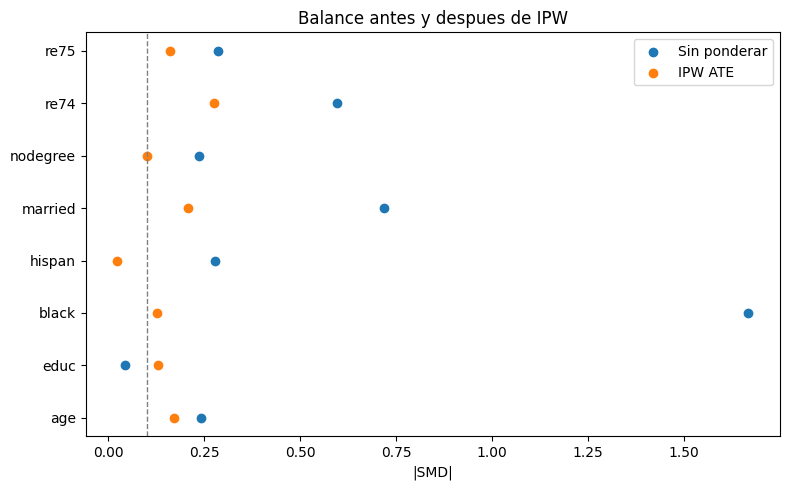

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ypos = np.arange(len(balance))

ax.scatter(balance["abs_smd_unweighted"], ypos, label="Sin ponderar")
ax.scatter(balance["abs_smd_ipw_ate"], ypos, label="IPW ATE")
ax.axvline(0.1, color="gray", linestyle="--", linewidth=1)
ax.set_yticks(ypos)
ax.set_yticklabels(balance["covariate"])
ax.set_xlabel("|SMD|")
ax.set_title("Balance antes y despues de IPW")
ax.legend()
fig.tight_layout()

balance_plot_path = OUTPUT_DIR / "balance_smd.png"
fig.savefig(balance_plot_path, dpi=160)
balance_plot_path

## Estimadores IPW y comparacion inicial

Calculamos la diferencia cruda de medias, el ATE por IPW y una version normalizada del estimador IPW. La comparacion sirve para evaluar sensibilidad.

In [12]:
ate_naive = df.loc[d == 1, Y].mean() - df.loc[d == 0, Y].mean()

ate_ipw = np.mean(d * y / e) - np.mean((1 - d) * y / (1 - e))

ate_ipw_normalized = (
    np.sum(d * y / e) / np.sum(d / e)
    - np.sum((1 - d) * y / (1 - e)) / np.sum((1 - d) / (1 - e))
)

att_ipw = (
    df.loc[d == 1, Y].mean()
    - np.sum((1 - d) * e * y / (1 - e)) / np.sum((1 - d) * e / (1 - e))
)

ipw_results = pd.DataFrame({
    "estimador": ["Diferencia cruda", "ATE IPW", "ATE IPW normalizado", "ATT IPW"],
    "estimacion": [ate_naive, ate_ipw, ate_ipw_normalized, att_ipw],
})
ipw_results

,estimador,estimacion
0,Diferencia cruda,-635.0262
1,ATE IPW,-536.1715
2,ATE IPW normalizado,232.4212
3,ATT IPW,"1,214.7822"


Si el ATE IPW no normalizado y el normalizado difieren de forma importante, esto no debe leerse como una contradiccion simple. Es evidencia de sensibilidad a pesos extremos y a falta de solapamiento perfecto.

## Modelo de resultados

Estimamos un modelo de resultados de la forma:

`E[Y | D, X]`

y generamos dos predicciones potenciales para cada individuo:

`m1(X) = E[Y | D = 1, X]`

`m0(X) = E[Y | D = 0, X]`

Luego:

`ATE = E[m1(X) - m0(X)]`

`ATT = E[m1(X) - m0(X) | D = 1]`

In [13]:
result_features = [D] + X_cols
X_result = df[result_features].copy()

outcome_model = LinearRegression()
outcome_model.fit(X_result, y)

X_treated = X_result.copy()
X_control = X_result.copy()
X_treated[D] = 1
X_control[D] = 0

mu1 = outcome_model.predict(X_treated)
mu0 = outcome_model.predict(X_control)

ate_outcome = np.mean(mu1 - mu0)
att_outcome = np.mean((mu1 - mu0)[d == 1])

weighted_outcome_model = LinearRegression()
weighted_outcome_model.fit(X_result, y, sample_weight=df["w_ate"])

mu1_w = weighted_outcome_model.predict(X_treated)
mu0_w = weighted_outcome_model.predict(X_control)

ate_outcome_ipw = np.mean(mu1_w - mu0_w)
att_outcome_ipw = np.mean((mu1_w - mu0_w)[d == 1])

outcome_results = pd.DataFrame({
    "estimador": [
        "ATE modelo de resultados",
        "ATT modelo de resultados",
        "ATE modelo de resultados con pesos IPW",
        "ATT modelo de resultados con pesos IPW",
    ],
    "estimacion": [ate_outcome, att_outcome, ate_outcome_ipw, att_outcome_ipw],
})
outcome_results

,estimador,estimacion
0,ATE modelo de resultados,"1,548.2438"
1,ATT modelo de resultados,"1,548.2438"
2,ATE modelo de resultados con pesos IPW,732.6367
3,ATT modelo de resultados con pesos IPW,732.6367


In [14]:
all_results = pd.concat([ipw_results, outcome_results], ignore_index=True)
all_results

,estimador,estimacion
0,Diferencia cruda,-635.0262
1,ATE IPW,-536.1715
2,ATE IPW normalizado,232.4212
3,ATT IPW,"1,214.7822"
4,ATE modelo de resultados,"1,548.2438"
5,ATT modelo de resultados,"1,548.2438"
6,ATE modelo de resultados con pesos IPW,732.6367
7,ATT modelo de resultados con pesos IPW,732.6367


La diferencia cruda de medias mezcla el efecto del programa con diferencias previas entre NSW y PSID. IPW intenta corregir este desbalance reponderando controles y tratados, pero puede ser inestable si los puntajes de propension son extremos. El modelo de resultados suele ser mas estable, aunque depende de su especificacion y puede extrapolar en regiones donde no existen buenos controles comparables.

En este contexto, el ATT es especialmente relevante porque evalua el efecto del programa NSW sobre quienes efectivamente participaron. El ATE pregunta por el efecto promedio en toda la poblacion combinada NSW/PSID, lo cual es mas exigente cuando el solapamiento no es perfecto.

## DAG causal propuesto

El DAG propuesto representa que las covariables pretratamiento afectan tanto la probabilidad de recibir tratamiento como los ingresos posteriores.

```mermaid
flowchart LR
  A["age"] --> D["treat"]
  E["educ"] --> D
  B["black"] --> D
  H["hispan"] --> D
  M["married"] --> D
  N["nodegree"] --> D
  R74["re74"] --> D
  R75["re75"] --> D

  A --> Y["re78"]
  E --> Y
  B --> Y
  H --> Y
  M --> Y
  N --> Y
  R74 --> Y
  R75 --> Y

  E --> N
  R74 --> R75

  D --> Y
```

El nodo `ID` no aparece en el DAG porque no es una causa sustantiva del ingreso o del tratamiento; es un identificador que codifica el origen de la muestra.

## Conjunto de ajuste/backdoor

El conjunto de ajuste propuesto es:

`{age, educ, black, hispan, married, nodegree, re74, re75}`

Estas variables son pretratamiento y afectan plausiblemente tanto la participacion en el programa como el ingreso posterior. Al condicionar en ellas, se bloquean los caminos backdoor entre `treat` y `re78`.

La identificacion causal depende de dos supuestos fuertes:

1. Ignorabilidad condicional: no quedan confusores no observados despues de ajustar por `X`.
2. Positividad: para combinaciones relevantes de `X`, debe existir probabilidad positiva de observar tratamiento y control.

En este archivo, el solapamiento imperfecto NSW/PSID hace que la positividad practica sea una advertencia importante para interpretar ATE e IPW.